<a href="https://colab.research.google.com/github/mishal-2408/AI23531-DEEP-LEARNING/blob/main/THREE_LAYER_NEURAL_NETWORK_FROM_SCRATCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape : (10000, 28, 28)

Starting training...

Epoch [1/5], Loss: 0.090667
Epoch [2/5], Loss: 0.090298
Epoch [3/5], Loss: 0.090203
Epoch [4/5], Loss: 0.090115
Epoch [5/5], Loss: 0.082218

Training completed!

Accuracy on test data: 33.20%


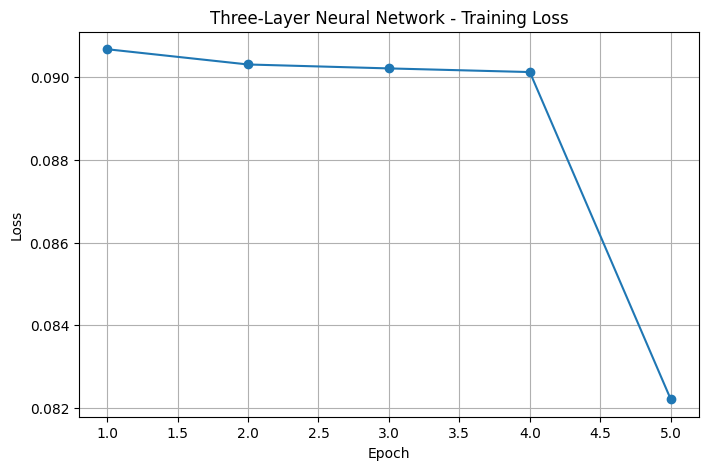

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import OneHotEncoder


# ==========================================
# STEP 1: LOAD AND PREPROCESS MNIST
# ==========================================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)


# Flatten images
X_train = X_train.reshape(
    X_train.shape[0],
    784
).astype("float32") / 255.0

X_test = X_test.reshape(
    X_test.shape[0],
    784
).astype("float32") / 255.0


# One-hot encode labels
encoder = OneHotEncoder(
    sparse_output=False
)

y_train = encoder.fit_transform(
    y_train.reshape(-1, 1)
)

y_test = encoder.transform(
    y_test.reshape(-1, 1)
)


# ==========================================
# STEP 2: DEFINE ACTIVATION FUNCTION
# ==========================================

def sigmoid(x):

    x = np.clip(
        x,
        -500,
        500
    )

    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):

    return x * (1 - x)


# ==========================================
# STEP 3: DEFINE THREE-LAYER NETWORK
# ==========================================

input_size = 784
hidden1_size = 128
hidden2_size = 64
output_size = 10

np.random.seed(42)


W1 = np.random.randn(
    input_size,
    hidden1_size
) * 0.01

b1 = np.zeros(
    (1, hidden1_size)
)


W2 = np.random.randn(
    hidden1_size,
    hidden2_size
) * 0.01

b2 = np.zeros(
    (1, hidden2_size)
)


W3 = np.random.randn(
    hidden2_size,
    output_size
) * 0.01

b3 = np.zeros(
    (1, output_size)
)


# ==========================================
# STEP 4: TRAIN NETWORK
# ==========================================

learning_rate = 0.1

num_epochs = 5

# Smaller subset makes from-scratch training
# practical in Google Colab
num_samples = 10000

loss_history = []


print("\nStarting training...\n")


for epoch in range(num_epochs):

    total_loss = 0.0

    for i in range(num_samples):

        # ----------------------------------
        # Forward propagation
        # ----------------------------------

        x = X_train[i:i + 1]

        target = y_train[i:i + 1]


        z1 = np.dot(
            x,
            W1
        ) + b1

        a1 = sigmoid(z1)


        z2 = np.dot(
            a1,
            W2
        ) + b2

        a2 = sigmoid(z2)


        z3 = np.dot(
            a2,
            W3
        ) + b3

        output = sigmoid(z3)


        # ----------------------------------
        # Calculate loss
        # ----------------------------------

        loss = np.mean(
            (target - output) ** 2
        )

        total_loss += loss


        # ----------------------------------
        # Backpropagation
        # ----------------------------------

        error3 = (
            target - output
        )

        delta3 = (
            error3 *
            sigmoid_derivative(output)
        )


        error2 = np.dot(
            delta3,
            W3.T
        )

        delta2 = (
            error2 *
            sigmoid_derivative(a2)
        )


        error1 = np.dot(
            delta2,
            W2.T
        )

        delta1 = (
            error1 *
            sigmoid_derivative(a1)
        )


        # ----------------------------------
        # Update weights
        # ----------------------------------

        W3 += learning_rate * np.dot(
            a2.T,
            delta3
        )

        b3 += learning_rate * delta3


        W2 += learning_rate * np.dot(
            a1.T,
            delta2
        )

        b2 += learning_rate * delta2


        W1 += learning_rate * np.dot(
            x.T,
            delta1
        )

        b1 += learning_rate * delta1


    epoch_loss = (
        total_loss /
        num_samples
    )

    loss_history.append(
        epoch_loss
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {epoch_loss:.6f}"
    )


print("\nTraining completed!")


# ==========================================
# STEP 5: EVALUATE NETWORK
# ==========================================

correct = 0

test_samples = 1000


for i in range(test_samples):

    x = X_test[i:i + 1]


    z1 = np.dot(
        x,
        W1
    ) + b1

    a1 = sigmoid(z1)


    z2 = np.dot(
        a1,
        W2
    ) + b2

    a2 = sigmoid(z2)


    z3 = np.dot(
        a2,
        W3
    ) + b3

    output = sigmoid(z3)


    prediction = np.argmax(
        output
    )

    actual = np.argmax(
        y_test[i]
    )


    if prediction == actual:

        correct += 1


accuracy = (
    100 *
    correct /
    test_samples
)


print(
    f"\nAccuracy on test data: "
    f"{accuracy:.2f}%"
)


# ==========================================
# STEP 6: PLOT TRAINING LOSS
# ==========================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, num_epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Three-Layer Neural Network - Training Loss"
)

plt.grid(True)

plt.show()